## STEP 0: What are we doing overall?

We are doing K-Means clustering on a small dataset.

K-Means will:

Take points

Group them into K clusters

Give each point a cluster label

In [1]:
import pandas as pd          #Used for tables (DataFrame) / Helpful to add column names, view data clearly
import numpy as np           # Used for numerical arrays /
import matplotlib.pyplot as plt               # Used for graphs & visualization
from sklearn.datasets import make_blobs       # Used to create sample datasets
from sklearn.cluster import KMeans            #The K-Means algorithm

In [2]:
X=np.array([[1,2],[1,4],[1,0],[10,4],[10,0]])       # created 5 data points Each point has 2 features (x, y)

In [3]:
X

array([[ 1,  2],
       [ 1,  4],
       [ 1,  0],
       [10,  4],
       [10,  0]])

visually :

(1,2)   (1,4)   (1,0)        → close together

(10,4)  (10,0)              → close together

So we EXPECT 2–3 clusters


In [4]:
X.shape   # It tells us how big our data is (number of rows, number of columns)


(5, 2)

In [5]:
X.dtype   #Shows data type

dtype('int64')

In [6]:
kmeans=KMeans(n_clusters=3)   # Create KMeans object

You want 3 clusters

Algorithm will find 3 centers

Rule:

If you don’t know K → use Elbow method

Here K is given manually

In [7]:
"""
This does ALL the work internally:
        Selects initial centroids
        Assigns points to nearest centroid
        Updates centroids
        Repeats until stable
"""


kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [8]:
kmeans.labels_    # stores the cluster number assigned to each data point after K-Means training.

array([0, 0, 0, 1, 2], dtype=int32)

In [9]:
X

array([[ 1,  2],
       [ 1,  4],
       [ 1,  0],
       [10,  4],
       [10,  0]])

In [10]:
X[:,0]    # All rows + first column

array([ 1,  1,  1, 10, 10])

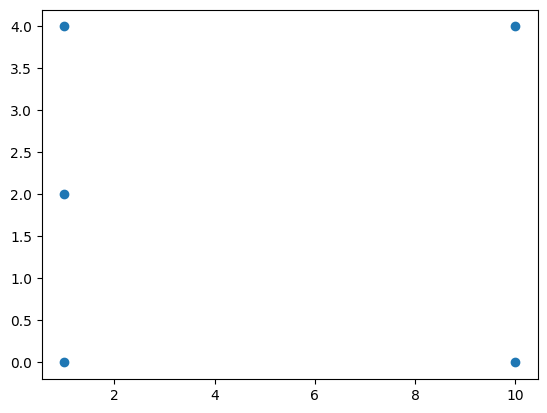

In [11]:
plt.scatter(X[:,0],X[:,1])    # Shows points on graph

In [12]:
# Convert NumPy array to DataFrame

data=pd.DataFrame(X)

In [17]:
data = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])


In [18]:
data

,Feature_1,Feature_2
0,1,2
1,1,4
2,1,0
3,10,4
4,10,0


## Remember this pattern (VERY IMPORTANT)

Whenever ML gives output as an array:

pd.DataFrame(output, columns=["Meaningful_Name"])


In [20]:
# It converts the KMeans labels into a table (DataFrame) And gives the column a proper name

labels = pd.DataFrame(kmeans.labels_, columns=["Cluster"])


In [21]:
datawithlabels=pd.concat([data,labels],axis=1)  # axis=1 = add column-wise

In [22]:
datawithlabels

,Feature_1,Feature_2,Cluster
0,1,2,0
1,1,4,0
2,1,0,0
3,10,4,1
4,10,0,2


In [26]:
kmeans.cluster_centers_    #It gives the center point of each cluster


array([[ 1.,  2.],
       [10.,  4.],
       [10.,  0.]])

In [30]:
test_data=np.array([[0,0],[12,3],[20,21]])

In [31]:
kmeans.predict(test_data)         #It tells which cluster a NEW data point belongs to

array([0, 1, 1], dtype=int32)

## for big random data 

In [33]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2,random_state=10)    #make)blobs generates raw data

In [34]:
X

array([[ 4.56889035, -9.9492391 ],
       [ 2.35388502,  3.51466401],
       [-0.01750156, -6.05038477],
       ...,
       [ 4.89123569,  4.86995972],
       [ 1.09272697,  4.04641343],
       [ 0.97077866, -4.8289551 ]], shape=(1000, 2))

In [35]:
y

array([0, 1, 2, 2, 1, 2, 2, 2, 2, 2, 0, 1, 0, 0, 2, 2, 2, 0, 0, 0, 2, 0,
       2, 2, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 2, 1, 1,
       0, 1, 2, 2, 0, 0, 0, 2, 1, 2, 1, 2, 2, 0, 1, 1, 2, 2, 0, 1, 2, 0,
       1, 0, 1, 1, 1, 2, 2, 0, 2, 2, 0, 0, 0, 2, 2, 2, 1, 2, 1, 0, 1, 2,
       2, 1, 1, 0, 0, 1, 2, 0, 1, 0, 0, 1, 1, 2, 1, 1, 2, 0, 2, 1, 0, 2,
       2, 1, 0, 1, 2, 0, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 1, 2,
       1, 2, 2, 2, 2, 0, 2, 2, 0, 1, 2, 0, 1, 0, 2, 1, 1, 2, 1, 0, 0, 2,
       2, 1, 2, 2, 1, 2, 1, 2, 0, 0, 1, 1, 1, 1, 0, 2, 1, 2, 2, 2, 0, 0,
       2, 0, 0, 0, 2, 2, 0, 2, 1, 1, 2, 2, 2, 1, 2, 2, 0, 0, 1, 0, 1, 1,
       2, 2, 2, 0, 1, 2, 0, 0, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 0, 0, 1, 2,
       1, 2, 0, 0, 2, 1, 2, 1, 0, 2, 1, 0, 1, 0, 2, 2, 0, 1, 2, 2, 1, 2,
       1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 1, 1, 1, 1, 2, 1, 1, 0, 0, 1, 2,
       1, 0, 2, 0, 1, 0, 0, 1, 2, 0, 2, 0, 1, 1, 0, 0, 0, 1, 2, 1, 1, 0,
       0, 0, 0, 2, 2, 1, 1, 1, 2, 1, 2, 0, 0, 2, 2,

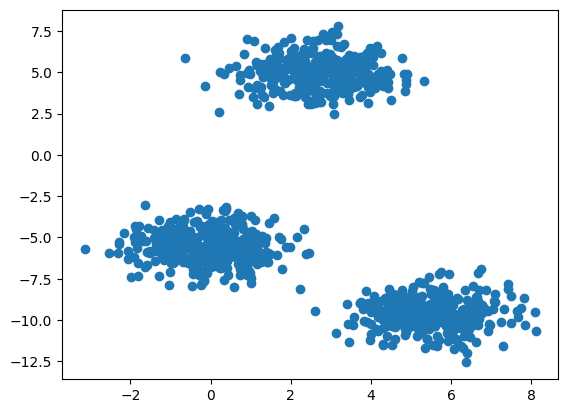

In [37]:
plt.scatter(X[:,0],X[:,1])

In [39]:
from sklearn.model_selection import train_test_split    #This function is used to split data into training and testing parts

In [40]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=20)

# (0.33)33% of data goes to test set
# Fixes randomness --> Ensures same split every time ==> Without it → data split changes every run

## kmeans.inertia_ returns the sum of squared distances of samples to their closest cluster center.

## Lower inertia_ generally means a better clustering fit, but WCSS naturally decreases as k increases.

## WCSS (Within-Cluster Sum of Squares) measures how tightly the data points in a cluster are grouped around the cluster center.

In [45]:
wcss=[]   # # List to store the WCSS values for each k
for k in range(2,11):           # Trying cluster counts from 2 to 10
    kmeans=KMeans(n_clusters=k,init="k-means++")          # Initialize KMeans
    kmeans.fit(X_train)                                   # Fit the model to your training data
    wcss.append(kmeans.inertia_)                          # inertia_ gives the WCSS for the fitted clusters

In [46]:
wcss

[6350.499237030181,
 1230.840526412377,
 1107.4590502329481,
 940.4743987335796,
 853.9606674438944,
 714.0108562673322,
 648.6940463469865,
 602.3595887034403,
 504.5887782708328]

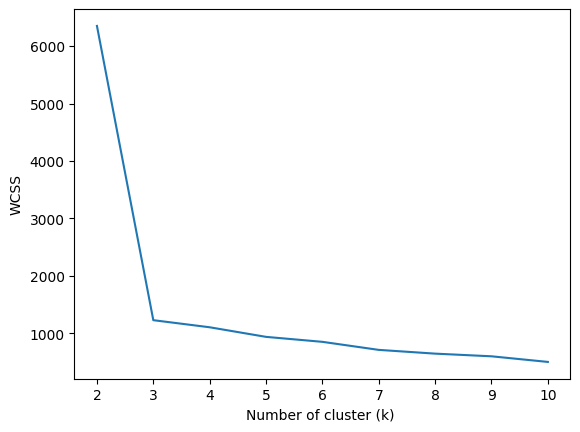

In [52]:
import matplotlib.pyplot as plt
plt.plot(range(2,11),wcss)
plt.xticks(range(2,11))
plt.xlabel("Number of cluster (k) ")
plt.ylabel("WCSS")
plt.show()

In [53]:
kmeans=KMeans(n_clusters=3,init="k-means++")          

In [54]:
y_labels=kmeans.fit_predict(X_train)

In [55]:
y_labels   #predicted data

array([2, 0, 2, 0, 2, 2, 0, 1, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 0, 1,
       0, 0, 1, 0, 1, 2, 0, 1, 2, 2, 1, 1, 1, 0, 0, 1, 0, 2, 0, 0, 1, 0,
       1, 0, 0, 2, 1, 2, 1, 1, 2, 1, 2, 2, 0, 2, 1, 2, 0, 1, 2, 1, 1, 2,
       2, 2, 1, 2, 0, 1, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 1, 2, 0, 1,
       0, 2, 0, 0, 0, 2, 2, 1, 1, 1, 1, 1, 2, 2, 1, 2, 0, 0, 2, 1, 0, 0,
       0, 2, 1, 2, 1, 0, 2, 2, 1, 1, 2, 2, 2, 0, 0, 2, 2, 1, 2, 2, 1, 2,
       2, 0, 0, 2, 0, 2, 0, 1, 0, 0, 1, 0, 0, 0, 2, 1, 0, 1, 0, 1, 1, 2,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 2, 0, 1, 0, 0, 1, 2, 1, 1, 2, 1, 2, 1,
       0, 0, 0, 1, 1, 2, 2, 1, 2, 1, 2, 0, 0, 0, 2, 0, 2, 1, 1, 1, 2, 1,
       0, 1, 1, 2, 1, 1, 1, 2, 0, 0, 2, 1, 0, 1, 1, 1, 0, 2, 2, 0, 0, 0,
       2, 0, 0, 2, 2, 1, 1, 2, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 0, 2, 1, 2,
       0, 0, 0, 1, 1, 0, 1, 0, 2, 1, 0, 1, 2, 1, 0, 1, 2, 2, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 2, 1, 1, 2, 2, 0, 1, 1, 1, 1, 2, 2, 0, 1, 1,
       2, 2, 1, 2, 0, 0, 2, 1, 1, 0, 2, 0, 1, 0, 2,

In [56]:
y_train      #actual data

array([2, 0, 2, 0, 2, 2, 0, 1, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 0, 1,
       0, 0, 1, 0, 1, 2, 0, 1, 2, 2, 1, 1, 1, 0, 0, 1, 0, 2, 0, 0, 1, 0,
       1, 0, 0, 2, 1, 2, 1, 1, 2, 1, 2, 2, 0, 2, 1, 2, 0, 1, 2, 1, 1, 2,
       2, 2, 1, 2, 0, 1, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 1, 2, 0, 1,
       0, 2, 0, 0, 0, 2, 2, 1, 1, 1, 1, 1, 2, 2, 1, 2, 0, 0, 2, 1, 0, 0,
       0, 2, 1, 2, 1, 0, 2, 2, 1, 1, 2, 2, 2, 0, 0, 2, 2, 1, 2, 2, 1, 2,
       2, 0, 0, 2, 0, 2, 0, 1, 0, 0, 1, 0, 0, 0, 2, 1, 0, 1, 0, 1, 1, 2,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 2, 0, 1, 0, 0, 1, 2, 1, 1, 2, 1, 2, 1,
       0, 0, 0, 1, 1, 2, 2, 1, 2, 1, 2, 0, 0, 0, 2, 0, 2, 1, 1, 1, 2, 1,
       0, 1, 1, 2, 1, 1, 1, 2, 0, 0, 2, 1, 0, 1, 1, 1, 0, 2, 2, 0, 0, 0,
       2, 0, 0, 2, 2, 1, 1, 2, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 0, 2, 1, 2,
       0, 0, 0, 1, 1, 0, 1, 0, 2, 1, 0, 1, 2, 1, 0, 1, 2, 2, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 2, 1, 1, 2, 2, 0, 1, 1, 1, 1, 2, 2, 0, 1, 1,
       2, 2, 1, 2, 0, 0, 2, 1, 1, 0, 2, 0, 1, 0, 2,

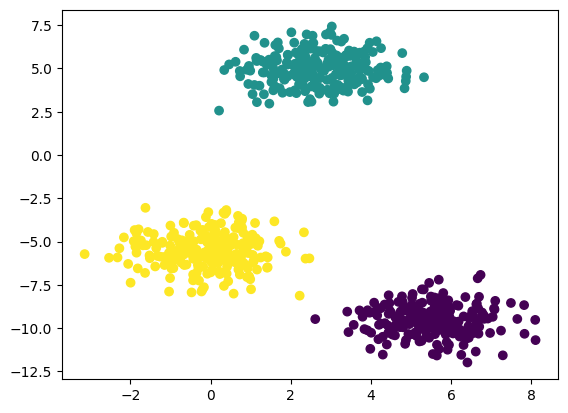

In [58]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)

## silhouetter --> It measures how well each data point fits into its assigned cluster compared to other clusters.
##  For a single point: --> s= b-a / max(a,b)  

In [61]:
from sklearn.metrics import silhouette_score  

In [62]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train)
    score=silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficients.append(score)

In [63]:
silhouette_coefficients

[0.7273220153669463,
 0.7835543034796946,
 0.6306654429022042,
 0.44401959867231666,
 0.3147738302545688,
 0.3189213077534144,
 0.3302332824754851,
 0.329941238272677,
 0.3255304320457119]

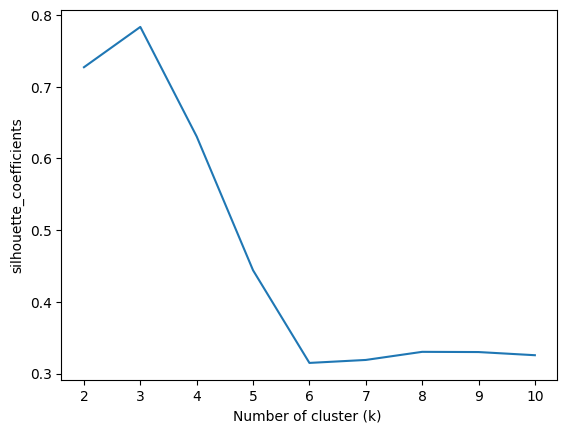

In [64]:
import matplotlib.pyplot as plt
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of cluster (k) ")
plt.ylabel("silhouette_coefficients")
plt.show()